In [1]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,Literal


In [2]:
class QuadEquation(TypedDict):
    a   :   int
    b   :   int
    c   :   int
    
    equation    :   str
    discriminant    :   float
    result  :   str

In [12]:
def showEquation(state : QuadEquation):
    equation = f"{state["a"]}X2 + {state["b"]}X + {state["c"]}"
    return {"equation"  :   equation}

def calculateDiscriminant(state : QuadEquation):
    discriminant = state["b"]**2-(4*state["a"]*state["c"])
    return {"discriminant": discriminant}


def realRoots(state : QuadEquation):
    root1 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    
    result = f"The roots are {root1} and {root2}"
    
    return {"result" : result}


def repeatedRoots(state : QuadEquation):
    root = (-state["b"])/(2*state["a"])
    result =f"Only repeating root is :{root}"
    return {"result":result}

def noRealRoots(state : QuadEquation):
    result =f"No real roots"
    return {"result":result}

def checkCondition(state : QuadEquation)->Literal["realRoots","repeatedRoots","noRealRoots"]:
    if state["discriminant"] >  0:
        return "realRoots"
    elif state["discriminant"] ==0:
        return "repeatedRoots" 
    else :
        return "noRealRoots"
           
    


In [13]:
graph = StateGraph(QuadEquation)

graph.add_node("showEquation",showEquation)
graph.add_node("calculateDiscriminant",calculateDiscriminant)
graph.add_node("realRoots",realRoots)
graph.add_node("repeatedRoots",repeatedRoots)
graph.add_node("noRealRoots",noRealRoots)

graph.add_edge(START,"showEquation")
graph.add_edge("showEquation","calculateDiscriminant")

graph.add_conditional_edges("calculateDiscriminant",checkCondition)

graph.add_edge("realRoots",END)
graph.add_edge("repeatedRoots",END)
graph.add_edge("noRealRoots",END)


workflow= graph.compile()



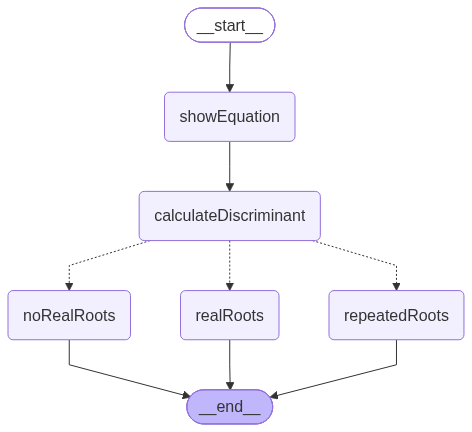

In [10]:
workflow

In [14]:
initialState={
    "a" :   5,
    "b" :   8,
    "c" :   2
}

workflow.invoke(initialState)

{'a': 5,
 'b': 8,
 'c': 2,
 'equation': '5X2 + 8X + 2',
 'discriminant': 24,
 'result': 'The roots are -1.2898979485566355 and -0.31010205144336445'}